In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time
from scipy.spatial.distance import cdist

In [3]:
def zdt1(x):
    """Evaluates the ZDT1 function for a population x."""
    n_vars = x.shape[1]
    f1 = x[:, 0]
    g = 1.0 + 9.0 * np.sum(x[:, 1:], axis=1) / (n_vars - 1)
    f2 = g * (1.0 - np.sqrt(f1 / g))
    return np.column_stack((f1, f2))

In [ ]:
def sbx_crossover(p1, p2, prob_cross, eta_cross):
    """Simulated Binary Crossover (SBX) with bounds checking."""
    c1, c2 = np.copy(p1), np.copy(p2)
    n_vars = p1.shape[1]
    
    for i in range(len(p1)):
        if np.random.rand() <= prob_cross:
            u = np.random.rand(n_vars)
            beta = np.where(u <= 0.5, 
                            (2.0 * u)**(1.0 / (eta_cross + 1.0)), 
                            (1.0 / (2.0 * (1.0 - u)))**(1.0 / (eta_cross + 1.0)))
            
            c1[i] = 0.5 * ((1 + beta) * p1[i] + (1 - beta) * p2[i])
            c2[i] = 0.5 * ((1 - beta) * p1[i] + (1 + beta) * p2[i])
            
            # Strict bounds enforcement
            c1[i] = np.clip(c1[i], 0.0, 1.0)
            c2[i] = np.clip(c2[i], 0.0, 1.0)
            
    return c1, c2

def polynomial_mutation(pop, prob_mut, eta_mut):
    """Bounded Polynomial Mutation for strict boundary convergence."""
    mutated = np.copy(pop)
    n_vars = pop.shape[1]
    
    for i in range(len(pop)):
        for j in range(n_vars):
            if np.random.rand() <= prob_mut:
                y = pop[i, j]
                yl, yu = 0.0, 1.0 # ZDT1 bounds
                
                if yl == yu: continue
                
                delta1 = (y - yl) / (yu - yl)
                delta2 = (yu - y) / (yu - yl)
                mut_pow = 1.0 / (eta_mut + 1.0)
                u = np.random.rand()
                
                if u <= 0.5:
                    xy = 1.0 - delta1
                    val = 2.0 * u + (1.0 - 2.0 * u) * (xy ** (eta_mut + 1.0))
                    delta_q = val ** mut_pow - 1.0
                else:
                    xy = 1.0 - delta2
                    val = 2.0 * (1.0 - u) + 2.0 * (u - 0.5) * (xy ** (eta_mut + 1.0))
                    delta_q = 1.0 - val ** mut_pow
                    
                y = y + delta_q * (yu - yl)

                y_clipped = np.clip(y, yl, yu)
                if y_clipped < 0.001: 
                    y_clipped = 0.0
                mutated[i, j] = y_clipped
                
    return mutated

In [5]:
def fast_non_dominated_sort(F):
    S = [[] for _ in range(len(F))]
    fronts = [[]]
    n = np.zeros(len(F), dtype=int)
    rank = np.zeros(len(F), dtype=int)

    for p in range(len(F)):
        dom_less_or_eq = np.all(F[p] <= F, axis=1)
        dom_less = np.any(F[p] < F, axis=1)
        dominates_q = dom_less_or_eq & dom_less
        
        S[p] = np.where(dominates_q)[0].tolist()
        n[p] = np.sum(np.all(F <= F[p], axis=1) & np.any(F < F[p], axis=1))
        
        if n[p] == 0:
            rank[p] = 0
            fronts[0].append(p)

    i = 0
    while len(fronts[i]) > 0:
        next_front = []
        for p in fronts[i]:
            for q in S[p]:
                n[q] -= 1
                if n[q] == 0:
                    rank[q] = i + 1
                    next_front.append(q)
        i += 1
        fronts.append(next_front)
    return fronts[:-1], rank

def crowding_distance(F, front):
    distances = np.zeros(len(front))
    if len(front) <= 2: 
        return np.full(len(front), np.inf)

    obj_front = F[front]
    for m in range(F.shape[1]):
        sorted_idx = np.argsort(obj_front[:, m])
        distances[sorted_idx[0]] = np.inf
        distances[sorted_idx[-1]] = np.inf
        
        f_min, f_max = obj_front[sorted_idx[0], m], obj_front[sorted_idx[-1], m]
        if f_max == f_min: continue
        
        for i in range(1, len(front) - 1):
            distances[sorted_idx[i]] += (obj_front[sorted_idx[i+1], m] - obj_front[sorted_idx[i-1], m]) / (f_max - f_min)
    return distances

def nsga2_step(pop, pop_size, prob_cross, eta_cross, prob_mut, eta_mut):
    current_objs = zdt1(pop)
    fronts, _ = fast_non_dominated_sort(current_objs)
    
    ranks = np.zeros(pop_size)
    distances = np.zeros(pop_size)
    for i, front in enumerate(fronts):
        distances[front] = crowding_distance(current_objs, front)
        for idx in front:
            ranks[idx] = i
            
    # Crowded Binary Tournament Selection
    mating_pool = np.empty_like(pop)
    for i in range(pop_size):
        a, b = np.random.randint(0, pop_size, 2)
        if ranks[a] < ranks[b]: mating_pool[i] = pop[a]
        elif ranks[b] < ranks[a]: mating_pool[i] = pop[b]
        else: mating_pool[i] = pop[a] if distances[a] > distances[b] else pop[b]
            
    p1, p2 = mating_pool[::2], mating_pool[1::2]
    offspring1, offspring2 = sbx_crossover(p1, p2, prob_cross, eta_cross)
    offspring = polynomial_mutation(np.vstack((offspring1, offspring2)), prob_mut, eta_mut)
    
    combined_pop = np.vstack((pop, offspring[:pop_size]))
    combined_objs = zdt1(combined_pop)
    comb_fronts, _ = fast_non_dominated_sort(combined_objs)
    
    next_pop = []
    for front in comb_fronts:
        if len(next_pop) + len(front) <= pop_size:
            next_pop.extend(front)
        else:
            dist = crowding_distance(combined_objs, front)
            sorted_front = [x for _, x in sorted(zip(dist, front), reverse=True)]
            next_pop.extend(sorted_front[:pop_size - len(next_pop)])
            break
            
    return combined_pop[next_pop]

In [ ]:
def spea2_step(pop, archive, pop_size, prob_cross, eta_cross, prob_mut, eta_mut):
    combined_pop = np.vstack((archive, pop)) if len(archive) > 0 else pop
    combined_F = zdt1(combined_pop)
    N_comb = len(combined_F)
    
    # SPEA2 Fitness Assignment
    S, R = np.zeros(N_comb), np.zeros(N_comb)
    dom_matrix = np.zeros((N_comb, N_comb), dtype=bool)
    for i in range(N_comb):
        dom_matrix[i] = np.all(combined_F[i] <= combined_F, axis=1) & np.any(combined_F[i] < combined_F, axis=1)
        S[i] = np.sum(dom_matrix[i])

    for i in range(N_comb):
        R[i] = np.sum(S[dom_matrix[:, i]])
        
    k = int(np.sqrt(N_comb))
    distances = cdist(combined_F, combined_F)
    kth_distance = np.sort(distances, axis=1)[:, k]
    Fitness = R + (1.0 / (kth_distance + 2.0))
    
    # Environmental Selection (Archive Truncation)
    next_archive_idx = np.where(Fitness < 1)[0].tolist()
    
    if len(next_archive_idx) < pop_size:
        sorted_by_fitness = np.argsort(Fitness)
        for idx in sorted_by_fitness:
            if idx not in next_archive_idx:
                next_archive_idx.append(idx)
            if len(next_archive_idx) == pop_size: break
            
    elif len(next_archive_idx) > pop_size:
        # Truncation based on distance to neighbors in objective space
        while len(next_archive_idx) > pop_size:
            sub_F = combined_F[next_archive_idx]
            sub_dist = cdist(sub_F, sub_F)
            np.fill_diagonal(sub_dist, np.inf) # Ignore distance to self
            sub_dist_sorted = np.sort(sub_dist, axis=1)
            
            # Find the individual with the smallest distance to its neighbors
            # Python's tuple comparison perfectly mimics SPEA-II tie-breaking (k=1, then k=2, etc.)
            to_remove_idx = min(range(len(next_archive_idx)), key=lambda i: tuple(sub_dist_sorted[i]))
            next_archive_idx.pop(to_remove_idx)

    new_archive = combined_pop[next_archive_idx]
    archive_fitness = Fitness[next_archive_idx]
    
    # Mating Selection (Binary Tournament on Archive)
    mating_pool = np.empty((pop_size, new_archive.shape[1]))
    for i in range(pop_size):
        a, b = np.random.randint(0, len(new_archive), 2)
        mating_pool[i] = new_archive[a] if archive_fitness[a] < archive_fitness[b] else new_archive[b]
        
    p1, p2 = mating_pool[::2], mating_pool[1::2]
    offspring1, offspring2 = sbx_crossover(p1, p2, prob_cross, eta_cross)
    new_pop = polynomial_mutation(np.vstack((offspring1, offspring2)), prob_mut, eta_mut)
    
    return new_pop[:pop_size], new_archive

In [7]:
def calculate_2d_hypervolume(front_objs, ref_point=np.array([1.2, 11.0])):
    """Calculates 2D Hypervolume with a dynamic reference point for early generations."""
    fronts, _ = fast_non_dominated_sort(front_objs)
    nd_front = front_objs[fronts[0]]
    nd_front = nd_front[np.argsort(nd_front[:, 0])] # Sort by f1
    
    hv = 0.0
    for i in range(len(nd_front)):
        width = (ref_point[0] - nd_front[i, 0]) if i == 0 else (nd_front[i-1, 0] - nd_front[i, 0])
        height = ref_point[1] - nd_front[i, 1]
        if width > 0 and height > 0:
            hv += width * height
    return hv

In [8]:
# Parameters
n_vars = 30
pop_size = 100
n_gens = 200
n_runs = 20
prob_cross, eta_cross = 0.9, 15
prob_mut, eta_mut = 2.0 / n_vars, 20

exec_times = {"NSGA-II": [], "SPEA-II": []}
hv_history = {"NSGA-II": np.zeros((n_runs, n_gens)), "SPEA-II": np.zeros((n_runs, n_gens))}
best_hv_found = {"NSGA-II": 0.0, "SPEA-II": 0.0}
best_fronts = {"NSGA-II": None, "SPEA-II": None}

for algo in ["NSGA-II", "SPEA-II"]:
    print(f"Executing {n_runs} runs for {algo}...")
    for run in range(n_runs):
        np.random.seed(run) 
        start_t = time.time()
        
        pop = np.random.rand(pop_size, n_vars)
        initial_pop = pop.copy() # For potential analysis of initial diversity
        if algo == "SPEA-II":
            archive = np.empty((0, n_vars))
            
        for gen in range(n_gens):
            if algo == "NSGA-II":
                pop = nsga2_step(pop, pop_size, prob_cross, eta_cross, prob_mut, eta_mut)
                objs = zdt1(pop)
            else:
                pop, archive = spea2_step(pop, archive, pop_size, prob_cross, eta_cross, prob_mut, eta_mut)
                objs = zdt1(archive)
                
            hv_history[algo][run, gen] = calculate_2d_hypervolume(objs)
            
        exec_times[algo].append(time.time() - start_t)
        
        # Save best front based on Final HV
        final_hv = hv_history[algo][run, -1]
        if final_hv > best_hv_found[algo]:
            best_hv_found[algo] = final_hv
            fronts, _ = fast_non_dominated_sort(objs)
            best_fronts[algo] = objs[fronts[0]].copy()

# Averaging Data
avg_times = {name: np.mean(times) for name, times in exec_times.items()}
avg_hv = {name: np.mean(hvs, axis=0) for name, hvs in hv_history.items()}

Executing 20 runs for NSGA-II...
Executing 20 runs for SPEA-II...


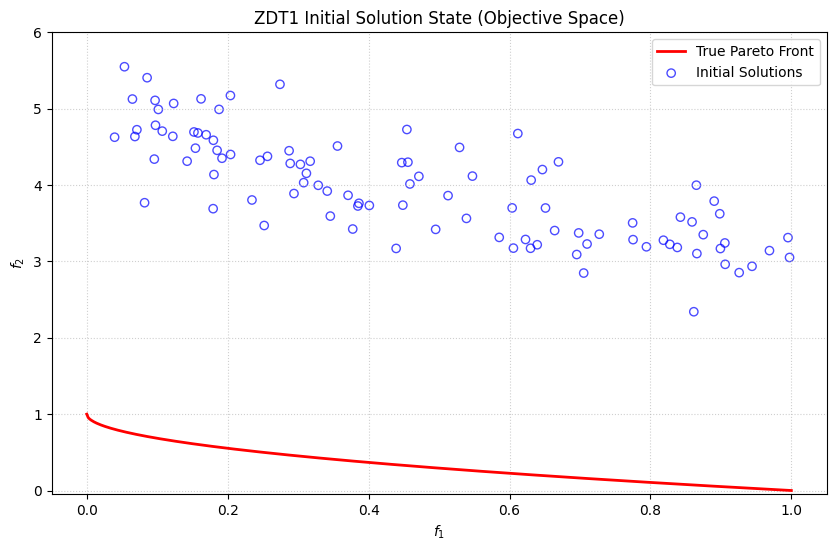

In [ ]:
# Evaluate Objectives (Objective Space)
# Calculates f1 and f2 for the initial random solutions
initial_objs = zdt1(initial_pop)

# Generate True Pareto Front Data for comparison
# ZDT1 true front is f2 = 1 - sqrt(f1) when g(x) = 1
objs_f1_theory = np.linspace(0, 1, 500)
objs_f2_theory = 1 - np.sqrt(objs_f1_theory)

# Plotting
plt.figure(figsize=(10, 6))

# Plot the theoretical true Pareto front
plt.plot(objs_f1_theory, objs_f2_theory, color='red', linewidth=2, label='True Pareto Front')

# Plot the initial random solutions
plt.scatter(initial_objs[:, 0], initial_objs[:, 1], 
            facecolors='none', edgecolors='blue', alpha=0.7, label='Initial Solutions')

plt.title("ZDT1 Initial Solution State (Objective Space)")
plt.xlabel("$f_1$")
plt.ylabel("$f_2$")
plt.xlim(-0.05, 1.05) # Add a little padding to the views
plt.ylim(-0.05, 6.0)  # g(x) makes initial f2 values high
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()

plt.show()

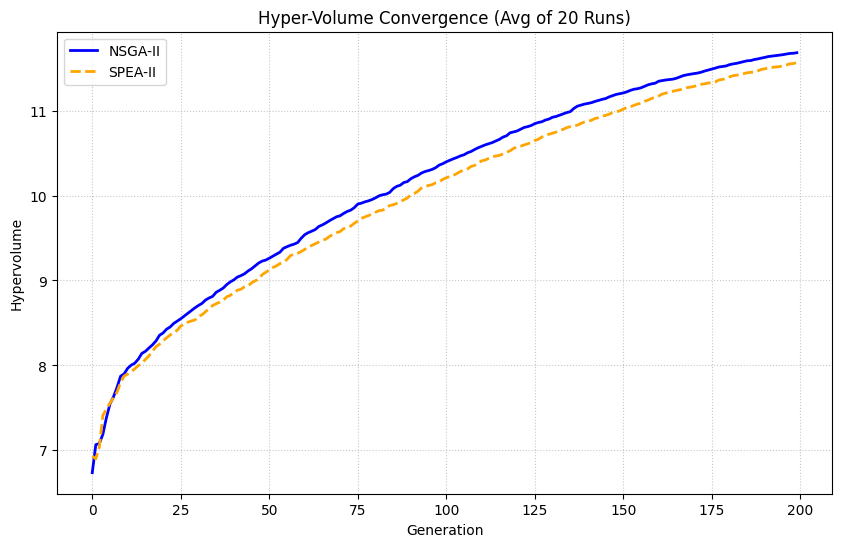

In [ ]:
# Plotting
plt.figure(figsize=(10, 6))

# Plot A: Convergence
plt.plot(avg_hv["NSGA-II"], label="NSGA-II", color="blue", linewidth=2)
plt.plot(avg_hv["SPEA-II"], label="SPEA-II", color="orange", linewidth=2, linestyle="--")
plt.title("Hyper-Volume Convergence (Avg of 20 Runs)")
plt.xlabel("Generation")
plt.ylabel("Hypervolume")
plt.grid(True, linestyle=":", alpha=0.7)
plt.savefig("ZDT1_Convergence.png")
plt.legend()

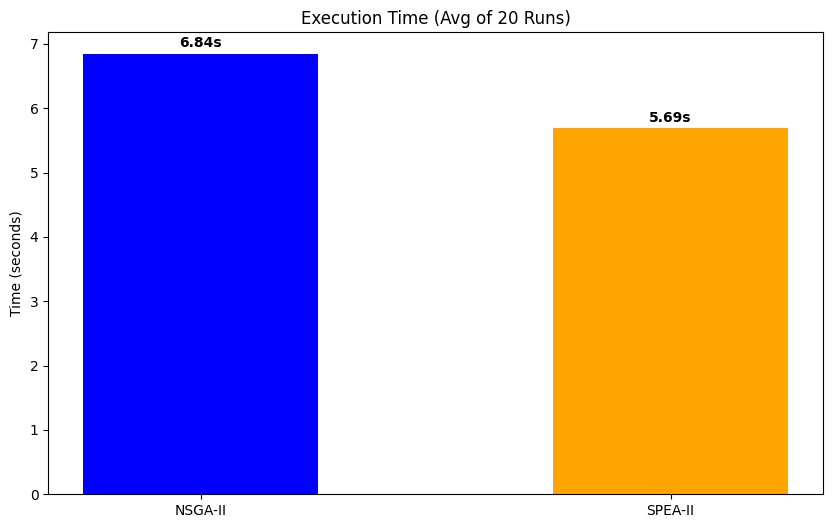

In [11]:
# Plot B: Times
plt.figure(figsize=(10, 6))
bars = plt.bar(avg_times.keys(), avg_times.values(), color=["blue", "orange"], width=0.5)
plt.title("Execution Time (Avg of 20 Runs)")
plt.ylabel("Time (seconds)")
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + (yval*0.01), f"{yval:.2f}s", ha="center", va="bottom", fontweight="bold")
plt.savefig("ZDT1_Execution_Times.png")

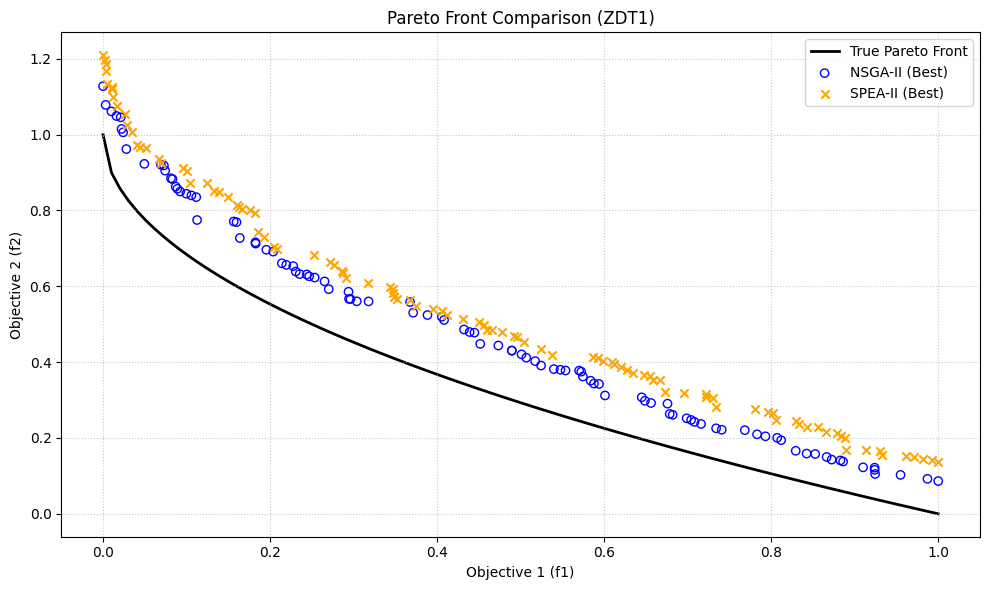

In [12]:
# Plot C: Pareto Front Comparison
plt.figure(figsize=(10, 6))
f1_true = np.linspace(0, 1, 100)
f2_true = 1 - np.sqrt(f1_true)
plt.plot(f1_true, f2_true, label="True Pareto Front", color="black", linewidth=2, zorder=1)
plt.scatter(best_fronts["NSGA-II"][:, 0], best_fronts["NSGA-II"][:, 1], label="NSGA-II (Best)", color="blue", marker="o", facecolors='none', zorder=2)
plt.scatter(best_fronts["SPEA-II"][:, 0], best_fronts["SPEA-II"][:, 1], label="SPEA-II (Best)", color="orange", marker="x", zorder=3)
plt.title("Pareto Front Comparison (ZDT1)")
plt.xlabel("Objective 1 (f1)")
plt.ylabel("Objective 2 (f2)")
plt.grid(True, linestyle=":", alpha=0.7)
plt.legend()

plt.tight_layout()
plt.savefig("ZDT1_Pareto_Front")
plt.show()